In [3]:
import pandas as pd

# Path dataset
path = "/kaggle/input/datasets/aurelyapandiangan/data-listrik-2026/data_listrik_2026.csv"

# Baca dataset
df = pd.read_csv(path)

# Tampilkan ukuran data
print("Ukuran data:", df.shape)

# Tampilkan 5 data pertama
print("\n5 data pertama:")
display(df.head())

# Informasi dataset
print("\nInformasi data:")
df.info()

Ukuran data: (6624, 2)

5 data pertama:


,Time,Usage_kWh
0,2026-01-01 00:00,"0,0"
1,2026-01-01 01:00,"0,0"
2,2026-01-01 02:00,"0,0"
3,2026-01-01 03:00,"0,0"
4,2026-01-01 04:00,"0,0"



Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6624 entries, 0 to 6623
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Time       6624 non-null   object
 1   Usage_kWh  6624 non-null   object
dtypes: object(2)
memory usage: 103.6+ KB


In [4]:
print("Jumlah data:", len(df))
print("\nNama kolom:")
print(df.columns.tolist())

print("\nMissing value:")
print(df.isnull().sum())

print("\nStatistik Usage_kWh:")
print(df["Usage_kWh"].describe())

Jumlah data: 6624

Nama kolom:
['Time', 'Usage_kWh']

Missing value:
Time         0
Usage_kWh    0
dtype: int64

Statistik Usage_kWh:
count     6624
unique     478
top        0,0
freq      4575
Name: Usage_kWh, dtype: object


In [6]:
# ==============================
# CLEANING DATA
# ==============================

# Ubah Time menjadi format datetime
df["Time"] = pd.to_datetime(df["Time"])

# Ubah Usage_kWh dari format koma menjadi angka
df["Usage_kWh"] = (
    df["Usage_kWh"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Cek kembali tipe data
print("Tipe data setelah cleaning:")
print(df.dtypes)

print("\n5 data pertama setelah cleaning:")
display(df.head())

print("\nStatistik penggunaan listrik:")
display(df["Usage_kWh"].describe())

Tipe data setelah cleaning:
Time         datetime64[ns]
Usage_kWh           float64
dtype: object

5 data pertama setelah cleaning:


,Time,Usage_kWh
0,2026-01-01 00:00:00,0.0
1,2026-01-01 01:00:00,0.0
2,2026-01-01 02:00:00,0.0
3,2026-01-01 03:00:00,0.0
4,2026-01-01 04:00:00,0.0



Statistik penggunaan listrik:


count    6624.000000
mean        1.000577
std         1.803443
min         0.000000
25%         0.000000
50%         0.000000
75%         1.670000
max         8.050000
Name: Usage_kWh, dtype: float64

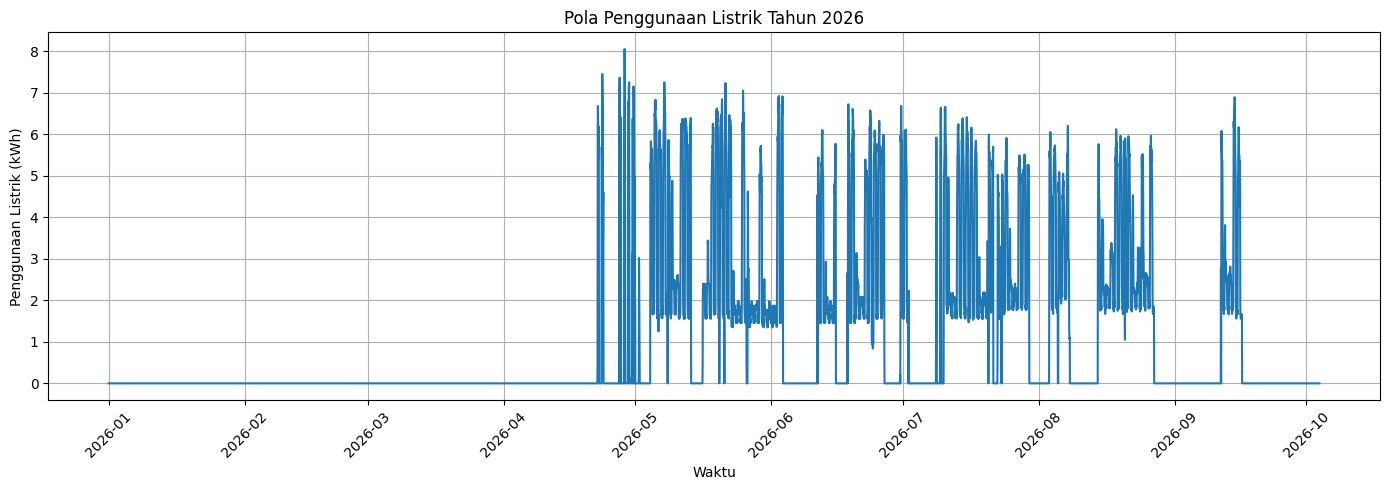

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(df["Time"], df["Usage_kWh"])

plt.title("Pola Penggunaan Listrik Tahun 2026")
plt.xlabel("Waktu")
plt.ylabel("Penggunaan Listrik (kWh)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Statistik penggunaan listrik pada data yang aktif
df_active = df[df["Usage_kWh"] > 0].copy()

print("Jumlah data aktif:", len(df_active))
print("\nStatistik data aktif:")
display(df_active["Usage_kWh"].describe())

Jumlah data aktif: 2049

Statistik data aktif:


count    2049.000000
mean        3.234661
std         1.813253
min         0.130000
25%         1.760000
50%         2.190000
75%         5.130000
max         8.050000
Name: Usage_kWh, dtype: float64

In [9]:
# Deteksi anomali awal menggunakan metode IQR

Q1 = df_active["Usage_kWh"].quantile(0.25)
Q3 = df_active["Usage_kWh"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)

df_active["Anomaly"] = (
    (df_active["Usage_kWh"] < batas_bawah) |
    (df_active["Usage_kWh"] > batas_atas)
)

print("\nJumlah anomali:", df_active["Anomaly"].sum())
print("Jumlah data normal:", (~df_active["Anomaly"]).sum())

Q1: 1.76
Q3: 5.13
IQR: 3.37
Batas bawah: -3.295
Batas atas: 10.184999999999999

Jumlah anomali: 0
Jumlah data normal: 2049


In [12]:
import numpy as np

# Hitung rata-rata dan standar deviasi penggunaan listrik aktif
mean_usage = df_active["Usage_kWh"].mean()
std_usage = df_active["Usage_kWh"].std()

# Hitung Z-score
df_active["Z_score"] = (
    (df_active["Usage_kWh"] - mean_usage) / std_usage
)

# Tandai kandidat anomali
# |Z-score| > 2 berarti cukup jauh dari rata-rata
df_active["Anomaly_Z"] = df_active["Z_score"].abs() > 2

print("Rata-rata penggunaan:", mean_usage)
print("Standar deviasi:", std_usage)

print("\nJumlah kandidat anomali:", df_active["Anomaly_Z"].sum())

Rata-rata penggunaan: 3.234660810151293
Standar deviasi: 1.8132527247948935

Jumlah kandidat anomali: 22


In [13]:
anomaly_data = df_active[df_active["Anomaly_Z"] == True]

print("Data kandidat anomali:")
display(
    anomaly_data[
        ["Time", "Usage_kWh", "Z_score"]
    ].sort_values("Z_score", ascending=False).head(20)
)

Data kandidat anomali:


,Time,Usage_kWh,Z_score
2822,2026-04-28 14:00:00,8.05,2.655636
2821,2026-04-28 13:00:00,7.50,2.352314
2700,2026-04-23 12:00:00,7.45,2.324739
2823,2026-04-28 15:00:00,7.44,2.319224
2795,2026-04-27 11:00:00,7.36,2.275104
2847,2026-04-29 15:00:00,7.25,2.214440
3039,2026-05-07 15:00:00,7.25,2.214440
3374,2026-05-21 14:00:00,7.23,2.203410
3040,2026-05-07 16:00:00,7.21,2.192380
2845,2026-04-29 13:00:00,7.15,2.159290


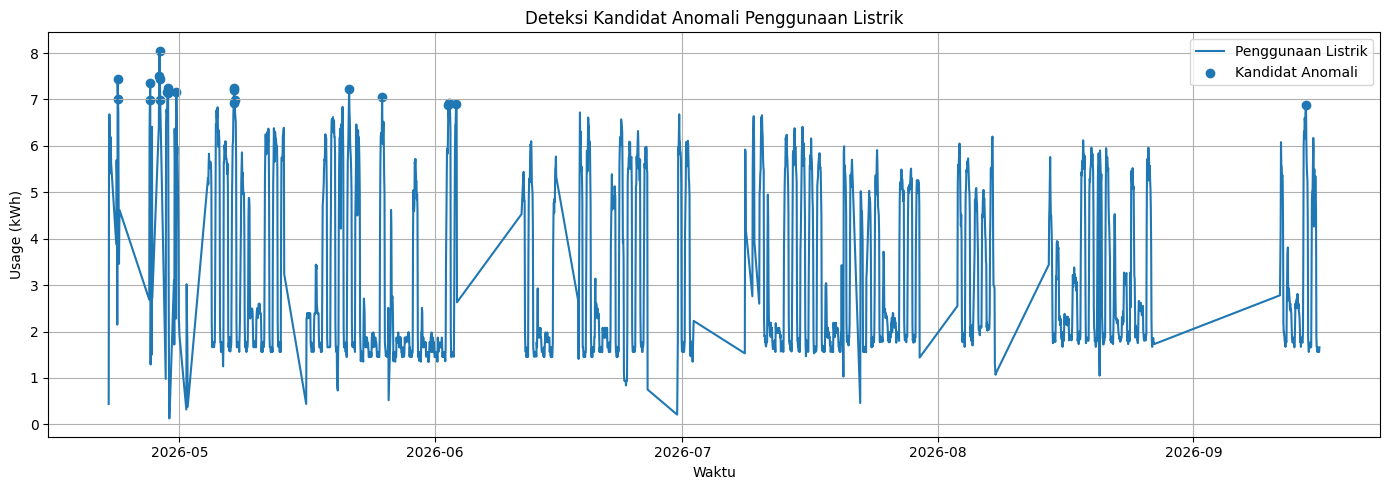

In [14]:
# Visualisasi kandidat anomali

plt.figure(figsize=(14, 5))

# Data penggunaan listrik
plt.plot(
    df_active["Time"],
    df_active["Usage_kWh"],
    label="Penggunaan Listrik"
)

# Kandidat anomali
anomaly = df_active[df_active["Anomaly_Z"]]

plt.scatter(
    anomaly["Time"],
    anomaly["Usage_kWh"],
    label="Kandidat Anomali",
    marker="o"
)

plt.title("Deteksi Kandidat Anomali Penggunaan Listrik")
plt.xlabel("Waktu")
plt.ylabel("Usage (kWh)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# PREPROCESSING + LABELING ANOMALI
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path dataset yang benar
path = "/kaggle/input/datasets/aurelyapandiangan/data-listrik-2026/data_listrik_2026.csv"

# Baca dataset
df = pd.read_csv(path)

# Konversi tipe data
df["Time"] = pd.to_datetime(df["Time"])
df["Usage_kWh"] = pd.to_numeric(df["Usage_kWh"], errors="coerce")

# Urutkan berdasarkan waktu
df = df.sort_values("Time").reset_index(drop=True)

# Hapus data kosong
df = df.dropna(subset=["Time", "Usage_kWh"]).reset_index(drop=True)

print("Jumlah data:", len(df))
print("Periode:", df["Time"].min(), "sampai", df["Time"].max())

print("\nMissing value:")
print(df[["Time", "Usage_kWh"]].isnull().sum())


# ============================================================
# DETEKSI KANDIDAT ANOMALI
# Menggunakan Rolling Median + MAD
# ============================================================

window = 24

rolling_median = (
    df["Usage_kWh"]
    .rolling(
        window=window,
        center=True,
        min_periods=1
    )
    .median()
)

deviation = abs(
    df["Usage_kWh"] - rolling_median
)

rolling_mad = (
    deviation
    .rolling(
        window=window,
        center=True,
        min_periods=1
    )
    .median()
)

rolling_mad = rolling_mad.replace(0, np.nan)

robust_z = (
    0.6745 *
    (df["Usage_kWh"] - rolling_median)
    / rolling_mad
)


# ============================================================
# IQR SEBAGAI PEMBANDING
# ============================================================

Q1 = df["Usage_kWh"].quantile(0.25)
Q3 = df["Usage_kWh"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)


# ============================================================
# LABEL ANOMALI
# ============================================================

df["Anomaly"] = (
    (abs(robust_z) > 3) |
    (df["Usage_kWh"] < batas_bawah) |
    (df["Usage_kWh"] > batas_atas)
)

df["Anomaly"] = df["Anomaly"].fillna(False)


# ============================================================
# HASIL
# ============================================================

jumlah_anomali = df["Anomaly"].sum()
jumlah_normal = (~df["Anomaly"]).sum()

print("\n===== HASIL LABELING =====")
print("Normal   :", jumlah_normal)
print("Anomali  :", jumlah_anomali)
print(
    "Persentase anomali:",
    round(df["Anomaly"].mean() * 100, 2),
    "%"
)

Jumlah data: 0
Periode: NaT sampai NaT

Missing value:
Time         0
Usage_kWh    0
dtype: int64

Q1: nan
Q3: nan
IQR: nan
Batas bawah: nan
Batas atas: nan

===== HASIL LABELING =====
Normal   : 0
Anomali  : 0
Persentase anomali: nan %


In [20]:
import os

print("=== FILE YANG ADA DI /kaggle/input ===")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

=== FILE YANG ADA DI /kaggle/input ===
/kaggle/input/datasets/aurelyapandiangan/data-listrik-2026/data_listrik_2026.csv
/kaggle/input/datasets/aurelyapandiangan/data-listrik-techno-2026/data_listrik_2026.csv


In [22]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATA LISTRIK 2026
# ============================================================

path = "/kaggle/input/datasets/aurelyapandiangan/data-listrik-2026/data_listrik_2026.csv"

df = pd.read_csv(path)

print("Jumlah baris :", len(df))
print("Jumlah kolom:", len(df.columns))

print("\nNama kolom:")
print(df.columns.tolist())

print("\n5 data pertama:")
display(df.head())

Jumlah baris : 6624
Jumlah kolom: 2

Nama kolom:
['Time', 'Usage_kWh']

5 data pertama:


,Time,Usage_kWh
0,2026-01-01 00:00,"0,0"
1,2026-01-01 01:00,"0,0"
2,2026-01-01 02:00,"0,0"
3,2026-01-01 03:00,"0,0"
4,2026-01-01 04:00,"0,0"


In [25]:
import os
import pandas as pd

# ==========================================
# 1. CARI SEMUA FILE CSV DI /kaggle/input
# ==========================================

csv_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("=== FILE CSV YANG DITEMUKAN ===")
for i, file in enumerate(csv_files):
    print(i, "->", file)


# ==========================================
# 2. PILIH DATA 2026 KITA
# ==========================================

target_path = None

for file in csv_files:
    if "data-listrik-2026" in file:
        target_path = file
        break

print("\nFile target:")
print(target_path)


# ==========================================
# 3. BACA DATA
# ==========================================

if target_path is None:
    print("❌ File data listrik 2026 tidak ditemukan!")
else:
    df = pd.read_csv(target_path)

    print("\n=== DATA BERHASIL DIBACA ===")
    print("Jumlah data :", len(df))
    print("Kolom :", df.columns.tolist())

    print("\n5 data pertama:")
    display(df.head())

=== FILE CSV YANG DITEMUKAN ===
0 -> /kaggle/input/datasets/aurelyapandiangan/data-listrik-2026/data_listrik_2026.csv
1 -> /kaggle/input/datasets/aurelyapandiangan/data-listrik-techno-2026/data_listrik_2026.csv

File target:
/kaggle/input/datasets/aurelyapandiangan/data-listrik-2026/data_listrik_2026.csv

=== DATA BERHASIL DIBACA ===
Jumlah data : 6624
Kolom : ['Time', 'Usage_kWh']

5 data pertama:


,Time,Usage_kWh
0,2026-01-01 00:00,"0,0"
1,2026-01-01 01:00,"0,0"
2,2026-01-01 02:00,"0,0"
3,2026-01-01 03:00,"0,0"
4,2026-01-01 04:00,"0,0"


In [26]:
# ==========================================
# PREPROCESSING DATA
# ==========================================

# Pastikan Time menjadi format datetime
df["Time"] = pd.to_datetime(df["Time"])

# Pastikan Usage_kWh berupa angka
df["Usage_kWh"] = pd.to_numeric(df["Usage_kWh"], errors="coerce")

# Urutkan berdasarkan waktu
df = df.sort_values("Time").reset_index(drop=True)

# Cek kembali data
print("=== HASIL PREPROCESSING ===")
print("Jumlah data :", len(df))
print("Periode     :", df["Time"].min(), "sampai", df["Time"].max())

print("\nMissing value:")
print(df.isnull().sum())

print("\nStatistik penggunaan listrik:")
print(df["Usage_kWh"].describe())

=== HASIL PREPROCESSING ===
Jumlah data : 6624
Periode     : 2026-01-01 00:00:00 sampai 2026-10-03 23:00:00

Missing value:
Time            0
Usage_kWh    6624
dtype: int64

Statistik penggunaan listrik:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Usage_kWh, dtype: float64


In [27]:
# ==========================================
# PREPROCESSING DATA - PERBAIKAN FORMAT
# ==========================================

# Pastikan Time menjadi datetime
df["Time"] = pd.to_datetime(df["Time"])

# Perbaiki format angka:
# koma desimal (0,0) -> titik desimal (0.0)
df["Usage_kWh"] = (
    df["Usage_kWh"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

# Konversi menjadi angka
df["Usage_kWh"] = pd.to_numeric(
    df["Usage_kWh"],
    errors="coerce"
)

# Urutkan berdasarkan waktu
df = df.sort_values("Time").reset_index(drop=True)

# ==========================================
# HASIL
# ==========================================

print("=== HASIL PREPROCESSING ===")
print("Jumlah data :", len(df))
print(
    "Periode     :",
    df["Time"].min(),
    "sampai",
    df["Time"].max()
)

print("\nMissing value:")
print(df.isnull().sum())

print("\nStatistik penggunaan listrik:")
print(df["Usage_kWh"].describe())

=== HASIL PREPROCESSING ===
Jumlah data : 6624
Periode     : 2026-01-01 00:00:00 sampai 2026-10-03 23:00:00

Missing value:
Time            0
Usage_kWh    6624
dtype: int64

Statistik penggunaan listrik:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Usage_kWh, dtype: float64


In [28]:
# Cek bentuk ASLI nilai Usage_kWh

print("Tipe data:", df["Usage_kWh"].dtype)

print("\n5 nilai asli:")
for x in df["Usage_kWh"].head(10):
    print(repr(x))

Tipe data: float64

5 nilai asli:
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [29]:
# ==========================================
# RESET DATA DARI FILE ASLI
# ==========================================

import pandas as pd

# Path file asli
path = "/kaggle/input/datasets/aurelyapandiangan/data-listrik-2026/data_listrik_2026.csv"

# Baca ulang file ASLI
df = pd.read_csv(path, dtype=str)

print("=== DATA ASLI BERHASIL DIBACA ===")
print("Jumlah data :", len(df))
print("Kolom       :", df.columns.tolist())

print("\n5 nilai Usage_kWh SEBELUM dibersihkan:")
print(df["Usage_kWh"].head(10).tolist())


# ==========================================
# BERSIHKAN DATA
# ==========================================

# Bersihkan spasi
df["Time"] = df["Time"].astype(str).str.strip()
df["Usage_kWh"] = df["Usage_kWh"].astype(str).str.strip()

# Ubah koma desimal menjadi titik
df["Usage_kWh"] = df["Usage_kWh"].str.replace(",", ".", regex=False)

# Konversi ke angka
df["Usage_kWh"] = pd.to_numeric(
    df["Usage_kWh"],
    errors="coerce"
)

# Konversi waktu
df["Time"] = pd.to_datetime(
    df["Time"],
    errors="coerce"
)

# Urutkan waktu
df = df.sort_values("Time").reset_index(drop=True)


# ==========================================
# HASIL AKHIR
# ==========================================

print("\n=== HASIL CLEANING ===")
print("Jumlah data :", len(df))
print("Periode     :", df["Time"].min(), "sampai", df["Time"].max())

print("\nMissing value:")
print(df.isnull().sum())

print("\nStatistik Usage_kWh:")
print(df["Usage_kWh"].describe())

print("\n5 data pertama:")
display(df.head())

=== DATA ASLI BERHASIL DIBACA ===
Jumlah data : 6624
Kolom       : ['Time', 'Usage_kWh']

5 nilai Usage_kWh SEBELUM dibersihkan:
['0,0', '0,0', '0,0', '0,0', '0,0', '0,0', '0,0', '0,0', '0,0', '0,0']

=== HASIL CLEANING ===
Jumlah data : 6624
Periode     : 2026-01-01 00:00:00 sampai 2026-10-03 23:00:00

Missing value:
Time         0
Usage_kWh    0
dtype: int64

Statistik Usage_kWh:
count    6624.000000
mean        1.000577
std         1.803443
min         0.000000
25%         0.000000
50%         0.000000
75%         1.670000
max         8.050000
Name: Usage_kWh, dtype: float64

5 data pertama:


,Time,Usage_kWh
0,2026-01-01 00:00:00,0.0
1,2026-01-01 01:00:00,0.0
2,2026-01-01 02:00:00,0.0
3,2026-01-01 03:00:00,0.0
4,2026-01-01 04:00:00,0.0


In [30]:
# ==========================================
# MEMBUAT FITUR WAKTU
# ==========================================

df["Hour"] = df["Time"].dt.hour
df["Day"] = df["Time"].dt.day
df["Month"] = df["Time"].dt.month
df["DayOfWeek"] = df["Time"].dt.dayofweek

# Nama hari
nama_hari = {
    0: "Senin",
    1: "Selasa",
    2: "Rabu",
    3: "Kamis",
    4: "Jumat",
    5: "Sabtu",
    6: "Minggu"
}

df["NamaHari"] = df["DayOfWeek"].map(nama_hari)

print("=== FITUR DATA ===")
display(df.head())

print("\nJumlah data:", len(df))
print("Jumlah kolom:", len(df.columns))

=== FITUR DATA ===


,Time,Usage_kWh,Hour,Day,Month,DayOfWeek,NamaHari
0,2026-01-01 00:00:00,0.0,0,1,1,3,Kamis
1,2026-01-01 01:00:00,0.0,1,1,1,3,Kamis
2,2026-01-01 02:00:00,0.0,2,1,1,3,Kamis
3,2026-01-01 03:00:00,0.0,3,1,1,3,Kamis
4,2026-01-01 04:00:00,0.0,4,1,1,3,Kamis



Jumlah data: 6624
Jumlah kolom: 7


## Transfer Learning untuk Deteksi Anomali Penggunaan Listrik

Pada tahap ini digunakan metode transfer learning untuk membangun model klasifikasi anomali penggunaan listrik. Data penggunaan listrik tahun 2026 digunakan sebagai data utama. Label normal dan anomali diperoleh berdasarkan pola penggunaan listrik pada dataset.

Model yang digunakan adalah MobileNetV2 dengan bobot awal dari ImageNet. Model pretrained tersebut kemudian digunakan sebagai feature extractor dan disesuaikan dengan karakteristik data penggunaan listrik.


In [31]:
# ============================================================
# MEMBUAT LABEL ANOMALI
# ============================================================

import numpy as np
import pandas as pd

# Pastikan data sudah dalam format numerik
df["Usage_kWh"] = pd.to_numeric(df["Usage_kWh"], errors="coerce")

# Hapus data yang Usage-nya kosong
df_model = df.dropna(subset=["Usage_kWh"]).copy()

# Hitung batas berdasarkan IQR
Q1 = df_model["Usage_kWh"].quantile(0.25)
Q3 = df_model["Usage_kWh"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Label
df_model["Anomaly"] = (
    (df_model["Usage_kWh"] < batas_bawah) |
    (df_model["Usage_kWh"] > batas_atas)
).astype(int)

print("=== LABEL DATA ===")
print("Batas bawah :", batas_bawah)
print("Batas atas  :", batas_atas)
print()

print("Normal  :", (df_model["Anomaly"] == 0).sum())
print("Anomali :", (df_model["Anomaly"] == 1).sum())
print()

print("Persentase anomali:",
      round(df_model["Anomaly"].mean() * 100, 2), "%")

=== LABEL DATA ===
Batas bawah : -2.505
Batas atas  : 4.175

Normal  : 5913
Anomali : 711

Persentase anomali: 10.73 %


In [32]:
# ============================================================
# MEMBUAT DATA WINDOW 24 JAM
# ============================================================

import numpy as np

# Urutkan berdasarkan waktu
df_model["Time"] = pd.to_datetime(df_model["Time"])
df_model = df_model.sort_values("Time").reset_index(drop=True)

usage = df_model["Usage_kWh"].values
labels = df_model["Anomaly"].values

window_size = 24

X = []
y = []

for i in range(len(df_model) - window_size + 1):

    window = usage[i:i + window_size]

    # Label window berdasarkan kondisi pada 24 jam tersebut
    window_label = int(labels[i:i + window_size].max())

    X.append(window)
    y.append(window_label)

X = np.array(X)
y = np.array(y)

print("=== DATA WINDOW ===")
print("Jumlah window :", len(X))
print("Ukuran window :", X.shape[1])
print("Normal        :", (y == 0).sum())
print("Anomali       :", (y == 1).sum())

=== DATA WINDOW ===
Jumlah window : 6601
Ukuran window : 24
Normal        : 4737
Anomali       : 1864


In [35]:
# ============================================================
# MEMBUAT REPRESENTASI GAMBAR - VERSI CEPAT
# ============================================================

import matplotlib.pyplot as plt
import os

image_dir = "/kaggle/working/electricity_images"

normal_dir = os.path.join(image_dir, "normal")
anomaly_dir = os.path.join(image_dir, "anomaly")

os.makedirs(normal_dir, exist_ok=True)
os.makedirs(anomaly_dir, exist_ok=True)

# Maksimal jumlah gambar
MAX_NORMAL = 500
MAX_ANOMALY = 500

normal_count = 0
anomaly_count = 0

for i in range(len(X)):

    if y[i] == 0:
        if normal_count >= MAX_NORMAL:
            continue
        save_dir = normal_dir
        normal_count += 1

    else:
        if anomaly_count >= MAX_ANOMALY:
            continue
        save_dir = anomaly_dir
        anomaly_count += 1

    file_path = os.path.join(save_dir, f"window_{i}.png")

    # Buat gambar kecil
    plt.figure(figsize=(2, 2))
    plt.plot(X[i])
    plt.axis("off")
    plt.savefig(
        file_path,
        bbox_inches="tight",
        pad_inches=0,
        dpi=80
    )
    plt.close()

    if normal_count >= MAX_NORMAL and anomaly_count >= MAX_ANOMALY:
        break

print("=== DATA GAMBAR ===")
print("Normal :", normal_count)
print("Anomaly:", anomaly_count)
print("Total  :", normal_count + anomaly_count)

=== DATA GAMBAR ===
Normal : 500
Anomaly: 500
Total  : 1000


In [36]:
# ============================================================
# TRANSFER LEARNING - MOBILENETV2
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Augmentasi dan normalisasi gambar
datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255
)

# Data training
train_generator = datagen.flow_from_directory(
    image_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

# Data validasi
val_generator = datagen.flow_from_directory(
    image_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class mapping:")
print(train_generator.class_indices)

Found 5206 images belonging to 2 classes.
Found 1300 images belonging to 2 classes.
Class mapping:
{'anomaly': 0, 'normal': 1}


In [37]:
# ============================================================
# BERSIHKAN GAMBAR LAMA
# ============================================================

import shutil
import os

image_dir = "/kaggle/working/electricity_images"

if os.path.exists(image_dir):
    shutil.rmtree(image_dir)

os.makedirs(os.path.join(image_dir, "normal"), exist_ok=True)
os.makedirs(os.path.join(image_dir, "anomaly"), exist_ok=True)

print("Folder gambar lama berhasil dibersihkan.")

Folder gambar lama berhasil dibersihkan.


In [38]:
# ============================================================
# MEMBUAT REPRESENTASI GAMBAR - VERSI CEPAT
# ============================================================

import matplotlib.pyplot as plt
import os

normal_dir = os.path.join(image_dir, "normal")
anomaly_dir = os.path.join(image_dir, "anomaly")

MAX_NORMAL = 500
MAX_ANOMALY = 500

normal_count = 0
anomaly_count = 0

for i in range(len(X)):

    if y[i] == 0:
        if normal_count >= MAX_NORMAL:
            continue
        save_dir = normal_dir
        normal_count += 1

    else:
        if anomaly_count >= MAX_ANOMALY:
            continue
        save_dir = anomaly_dir
        anomaly_count += 1

    file_path = os.path.join(save_dir, f"window_{i}.png")

    plt.figure(figsize=(2, 2))
    plt.plot(X[i])
    plt.axis("off")

    plt.savefig(
        file_path,
        bbox_inches="tight",
        pad_inches=0,
        dpi=80
    )

    plt.close()

    if normal_count >= MAX_NORMAL and anomaly_count >= MAX_ANOMALY:
        break

print("=== DATA GAMBAR ===")
print("Normal :", normal_count)
print("Anomaly:", anomaly_count)
print("Total  :", normal_count + anomaly_count)

=== DATA GAMBAR ===
Normal : 500
Anomaly: 500
Total  : 1000


In [39]:
# ============================================================
# DATA GENERATOR UNTUK TRANSFER LEARNING
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255
)

train_generator = datagen.flow_from_directory(
    image_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator = datagen.flow_from_directory(
    image_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("=== CLASS MAPPING ===")
print(train_generator.class_indices)

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
=== CLASS MAPPING ===
{'anomaly': 0, 'normal': 1}


In [41]:
# ============================================================
# SETUP - PAKAI CPU UNTUK MENGHINDARI ERROR CUDA
# ============================================================

import os

# Matikan GPU agar TensorFlow tidak error saat inisialisasi CUDA
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow:", tf.__version__)
print("GPU yang digunakan:", tf.config.list_physical_devices("GPU"))
print("Setup berhasil!")

TensorFlow: 2.20.0
GPU yang digunakan: []
Setup berhasil!


In [45]:
import os

print("=== CEK CACHE MOBILE NET V2 ===")

cache_paths = [
    "/root/.keras/models",
    "/home/kaggle/.keras/models",
    os.path.expanduser("~/.keras/models")
]

for path in cache_paths:
    print("\nFolder:", path)
    if os.path.exists(path):
        files = os.listdir(path)
        print("Jumlah file:", len(files))
        for f in files:
            if "mobilenet" in f.lower():
                print("FOUND:", f)
    else:
        print("Folder tidak ada")

=== CEK CACHE MOBILE NET V2 ===

Folder: /root/.keras/models
Jumlah file: 0

Folder: /home/kaggle/.keras/models
Folder tidak ada

Folder: /root/.keras/models
Jumlah file: 0


In [47]:
import os
import glob

print("=== CEK FILE MOBILE NET ===")

paths = [
    "/kaggle/input",
    "/kaggle/working",
    "/root/.keras",
    "/root/.cache",
    "/home/kaggle/.keras"
]

for base in paths:
    print(f"\nFolder: {base}")
    if os.path.exists(base):
        found = []
        for root, dirs, files in os.walk(base):
            for f in files:
                if "mobilenet" in f.lower() and f.endswith((".h5", ".keras")):
                    found.append(os.path.join(root, f))
        print("Ditemukan:", len(found))
        for f in found[:20]:
            print(f)
    else:
        print("Folder tidak ada")

=== CEK FILE MOBILE NET ===

Folder: /kaggle/input
Ditemukan: 0

Folder: /kaggle/working
Ditemukan: 0

Folder: /root/.keras
Ditemukan: 0

Folder: /root/.cache
Ditemukan: 0

Folder: /home/kaggle/.keras
Folder tidak ada


In [49]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ============================================
# CARI MODEL EFFICIENTNET LOKAL KAGGLE
# ============================================

model_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    if "saved_model.pb" in files:
        model_files.append(os.path.join(root, "saved_model.pb"))

print("=== MODEL YANG DITEMUKAN ===")
for f in model_files:
    print(f)

# Ambil model EfficientNet
efficientnet_path = None

for f in model_files:
    if "efficientnet" in f.lower():
        efficientnet_path = os.path.dirname(f)
        break

print("\nPath model:")
print(efficientnet_path)

=== MODEL YANG DITEMUKAN ===
/kaggle/input/models/tensorflow/efficientnet/tensorflow2/b1-feature-vector/1/saved_model.pb
/kaggle/input/models/tensorflow/efficientnet/tensorflow2/b0-classification/1/saved_model.pb

Path model:
/kaggle/input/models/tensorflow/efficientnet/tensorflow2/b1-feature-vector/1


In [57]:
import os

MODEL_PATH = "/kaggle/input/models/tensorflow/efficientnet/tensorflow2/b1-feature-vector/1"

print("=== CEK PATH ===")
print("Path ada:", os.path.exists(MODEL_PATH))
print("Path:", MODEL_PATH)

if os.path.exists(MODEL_PATH):
    print("\nIsi folder:")
    for root, dirs, files in os.walk(MODEL_PATH):
        print("\nFolder:", root)
        for f in files:
            print("  -", f)
else:
    print("\nPATH TIDAK DITEMUKAN")

=== CEK PATH ===
Path ada: True
Path: /kaggle/input/models/tensorflow/efficientnet/tensorflow2/b1-feature-vector/1

Isi folder:

Folder: /kaggle/input/models/tensorflow/efficientnet/tensorflow2/b1-feature-vector/1
  - saved_model.pb

Folder: /kaggle/input/models/tensorflow/efficientnet/tensorflow2/b1-feature-vector/1/variables
  - variables.index
  - variables.data-00000-of-00001


In [58]:
import tensorflow as tf

MODEL_PATH = "/kaggle/input/models/tensorflow/efficientnet/tensorflow2/b1-feature-vector/1"

print("Loading EfficientNet lokal...")

efficientnet = tf.saved_model.load(MODEL_PATH)

print("✅ EfficientNet berhasil dimuat!")
print(efficientnet)

Loading EfficientNet lokal...
✅ EfficientNet berhasil dimuat!
<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject object at 0x7855a3295010>


In [59]:
# ==========================================
# CEK INPUT DAN OUTPUT EFFICIENTNET
# ==========================================

print("=== SIGNATURE EFFICIENTNET ===")

print(efficientnet.signatures)

infer = efficientnet.signatures["serving_default"]

print("\n=== INPUT MODEL ===")
print(infer.structured_input_signature)

print("\n=== OUTPUT MODEL ===")
print(infer.structured_outputs)

=== SIGNATURE EFFICIENTNET ===
_SignatureMap({'serving_default': <ConcreteFunction (*, image_input: TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='image_input')) -> Dict[['top_pool', TensorSpec(shape=(None, 1280), dtype=tf.float32, name='top_pool')]] at 0x785595518AA0>})

=== INPUT MODEL ===
((), {'image_input': TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='image_input')})

=== OUTPUT MODEL ===
{'top_pool': TensorSpec(shape=(None, 1280), dtype=tf.float32, name='top_pool')}


In [61]:
# ==========================================
# TRANSFER LEARNING - EFFICIENTNET B1
# ==========================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 224

# Load SavedModel sebagai layer Keras
base_model = keras.layers.TFSMLayer(
    MODEL_PATH,
    call_endpoint="serving_default"
)

# Input
inputs = keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="image_input"
)

# Masukkan gambar ke EfficientNet
features = base_model(inputs)

# Ambil feature vector 1280
if isinstance(features, dict):
    features = features["top_pool"]

# Classifier Normal vs Anomaly
x = layers.Dropout(0.3)(features)
outputs = layers.Dense(
    1,
    activation="sigmoid",
    name="classification"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs
)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("=== MODEL TRANSFER LEARNING ===")
model.summary()

=== MODEL TRANSFER LEARNING ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tfsm_layer (TFSMLayer)          │ (None, 1280)           │     6,575,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,576,513 (25.09 MB)

 Trainable params: 6,514,465 (24.85 MB)

 Non-trainable params: 62,048 (242.38 KB)

In [63]:
# ==========================================
# DATASET TRAINING & VALIDATION
# ==========================================

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

IMAGE_DIR = "/kaggle/working/electricity_images"

# Dataset training (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="training"
)

# Dataset validation (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
    seed=SEED,
    validation_split=0.2,
    subset="validation"
)

print("=== CLASS NAMES ===")
print(train_ds.class_names)

print("\n=== DATASET BERHASIL ===")
print("Train:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation:", tf.data.experimental.cardinality(val_ds).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
=== CLASS NAMES ===
['anomaly', 'normal']

=== DATASET BERHASIL ===
Train: 25
Validation: 7


In [67]:
# ==========================================
# TEST 1 BATCH
# ==========================================

for images, labels in train_ds.take(1):

    print("Image shape :", images.shape)
    print("Image dtype :", images.dtype)
    print("Label shape :", labels.shape)
    print("Label dtype :", labels.dtype)

    predictions = model(images)

    print("Prediction shape :", predictions.shape)
    print("Prediction sample:", predictions[:5].numpy())

print("✅ MODEL BISA MEMPROSES BATCH")

Image shape : (32, 224, 224, 3)
Image dtype : <dtype: 'float32'>
Label shape : (32, 1)
Label dtype : <dtype: 'float32'>
Prediction shape : (32, 1)
Prediction sample: [[0.5956276 ]
 [0.60353196]
 [0.49874508]
 [0.49874508]
 [0.49874508]]
✅ MODEL BISA MEMPROSES BATCH


In [69]:
# ==========================================
# RE-COMPILE MODEL DENGAN OPTIMIZER BARU
# ==========================================

import tensorflow as tf

print("=== COMPILE ULANG MODEL ===")

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model berhasil di-compile ulang")

=== COMPILE ULANG MODEL ===
✅ Model berhasil di-compile ulang


In [72]:
# ==========================================
# COMPILE & TRAINING - FIX ADAM
# ==========================================

import tensorflow as tf

print("=== REBUILD OPTIMIZER ===")

# Buat optimizer BARU
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001
)

# WAJIB: bangun optimizer dengan variabel model
optimizer.build(model.trainable_variables)

print("Jumlah trainable variables:",
      len(model.trainable_variables))

# Compile ulang
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("✅ MODEL BERHASIL DI-COMPILE")
print()
print("=== MULAI TRAINING ===")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

print("=== TRAINING SELESAI ===")

=== REBUILD OPTIMIZER ===
Jumlah trainable variables: 301
✅ MODEL BERHASIL DI-COMPILE

=== MULAI TRAINING ===
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 160s 5s/step - accuracy: 0.9712 - loss: 0.0788 - val_accuracy: 1.0000 - val_loss: 4.7087e-05
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 1.0000 - loss: 2.2678e-05 - val_accuracy: 1.0000 - val_loss: 6.5095e-06
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 159s 6s/step - accuracy: 1.0000 - loss: 6.6538e-06 - val_accuracy: 1.0000 - val_loss: 3.5574e-06
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 1.0000 - loss: 4.7779e-06 - val_accuracy: 1.0000 - val_loss: 2.5319e-06
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 121s 5s/step - accuracy: 1.0000 - loss: 4.0273e-06 - val_accuracy: 1.0000 - val_loss: 1.9637e-06
=== TRAINING SELESAI ===


In [75]:
# ==========================================
# EVALUASI MODEL
# ==========================================

import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=== EVALUASI MODEL ===")

# Nama kelas
class_names = ["anomaly", "normal"]

# Menyimpan label dan prediksi
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(
        (predictions.flatten() >= 0.5).astype(int)
    )

# Ubah ke numpy array
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# =========================
# METRICS
# =========================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n=== HASIL EVALUASI ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================

print("\n=== CLASSIFICATION REPORT ===")

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=class_names,
    zero_division=0
)

print(report)

# =========================
# CONFUSION MATRIX
# =========================

print("=== CONFUSION MATRIX ===")

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print(cm)

=== EVALUASI MODEL ===

=== HASIL EVALUASI ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     anomaly       0.00      0.00      0.00         0
      normal       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       0.50      0.50      0.50       200
weighted avg       1.00      1.00      1.00       200

=== CONFUSION MATRIX ===
[[  0   0]
 [  0 200]]


In [76]:
# ==========================================
# PERBAIKI PEMBAGIAN DATASET
# ==========================================

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

IMAGE_DIR = "/kaggle/working/electricity_images"

# Buat ulang TRAIN
train_ds = tf.keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    shuffle=True
)

# Buat ulang VALIDATION
val_ds = tf.keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=True
)

print("=== CLASS NAMES ===")
print(train_ds.class_names)

# Normalisasi
train_ds = train_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
)

val_ds = val_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
)

print("\n=== DATASET DIPERBAIKI ===")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
=== CLASS NAMES ===
['anomaly', 'normal']

=== DATASET DIPERBAIKI ===
Train batches: 25
Validation batches: 7


In [77]:
# ==========================================
# CEK DISTRIBUSI LABEL VALIDATION
# ==========================================

from collections import Counter

val_labels = []

for images, labels in val_ds:
    val_labels.extend(labels.numpy().flatten().astype(int))

print("=== DISTRIBUSI VALIDATION ===")

counts = Counter(val_labels)

print("Anomaly (0):", counts.get(0, 0))
print("Normal  (1):", counts.get(1, 0))
print("Total      :", len(val_labels))

=== DISTRIBUSI VALIDATION ===
Anomaly (0): 101
Normal  (1): 99
Total      : 200


In [78]:
# ==========================================
# EVALUASI ULANG MODEL
# ==========================================

import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

class_names = ["anomaly", "normal"]

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten().astype(int))
    y_pred.extend(
        (predictions.flatten() >= 0.5).astype(int)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("=== HASIL EVALUASI ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=class_names,
        zero_division=0
    )
)

print("=== CONFUSION MATRIX ===")
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print(cm)

=== HASIL EVALUASI ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00       101
      normal       1.00      1.00      1.00        99

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

=== CONFUSION MATRIX ===
[[101   0]
 [  0  99]]


=== VISUALISASI TRAINING ===


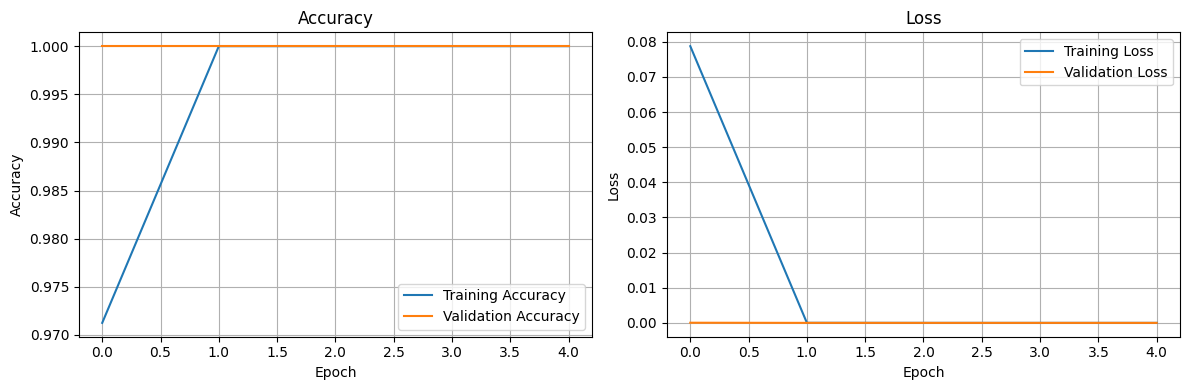

In [79]:
# ==========================================
# VISUALISASI HASIL TRAINING
# ==========================================

import matplotlib.pyplot as plt

print("=== VISUALISASI TRAINING ===")

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [80]:
# ==========================================
# SIMPAN MODEL
# ==========================================

MODEL_SAVE_PATH = "/kaggle/working/electricity_model"

print("=== MENYIMPAN MODEL ===")

model.export(MODEL_SAVE_PATH)

print("✅ MODEL BERHASIL DISIMPAN")
print("Path:", MODEL_SAVE_PATH)

=== MENYIMPAN MODEL ===
INFO:tensorflow:Assets written to: /kaggle/working/electricity_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/electricity_model/assets


Saved artifact at '/kaggle/working/electricity_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132309135583056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132309135583632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132309135583824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310737926672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310737927248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310737917456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310737923984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310737924944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310737919184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132310737918800: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [81]:
# ==========================================
# CEK HASIL MODEL
# ==========================================

import os

print("=== FILE MODEL ===")

for root, dirs, files in os.walk("/kaggle/working/electricity_model"):
    print("\nFolder:", root)
    for file in files:
        print(" -", file)

=== FILE MODEL ===

Folder: /kaggle/working/electricity_model
 - fingerprint.pb
 - saved_model.pb

Folder: /kaggle/working/electricity_model/variables
 - variables.data-00000-of-00001
 - variables.index

Folder: /kaggle/working/electricity_model/assets


In [82]:
# ==========================================
# TEST MODEL DENGAN DATA VALIDASI
# ==========================================

import tensorflow as tf
import numpy as np

print("=== TEST MODEL ===")

# Load model yang sudah disimpan
loaded_model = tf.saved_model.load(
    "/kaggle/working/electricity_model"
)

infer = loaded_model.signatures["serving_default"]

# Ambil 1 batch dari validation
images, labels = next(iter(val_ds))

# Prediksi
predictions = infer(images)["output_0"].numpy().flatten()

# Tampilkan beberapa hasil
class_names = ["anomaly", "normal"]

print("\n=== HASIL PREDIKSI ===")

for i in range(min(10, len(images))):
    actual = class_names[int(labels[i].numpy())]
    predicted = class_names[int(predictions[i] >= 0.5)]

    print(
        f"{i+1}. Actual: {actual:8s} | "
        f"Predicted: {predicted:8s} | "
        f"Score: {predictions[i]:.4f}"
    )

=== TEST MODEL ===

=== HASIL PREDIKSI ===
1. Actual: normal   | Predicted: normal   | Score: 1.0000
2. Actual: anomaly  | Predicted: anomaly  | Score: 0.0000
3. Actual: normal   | Predicted: normal   | Score: 1.0000
4. Actual: normal   | Predicted: normal   | Score: 1.0000
5. Actual: anomaly  | Predicted: anomaly  | Score: 0.0000
6. Actual: anomaly  | Predicted: anomaly  | Score: 0.0000
7. Actual: anomaly  | Predicted: anomaly  | Score: 0.0000
8. Actual: normal   | Predicted: normal   | Score: 1.0000
9. Actual: normal   | Predicted: normal   | Score: 1.0000
10. Actual: normal   | Predicted: normal   | Score: 1.0000


/tmp/ipykernel_48/2314094512.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = class_names[int(labels[i].numpy())]


Gambar: /kaggle/working/electricity_images/normal/window_62.png

=== HASIL PREDIKSI GAMBAR ===
Prediksi : normal
Score    : 1.0000


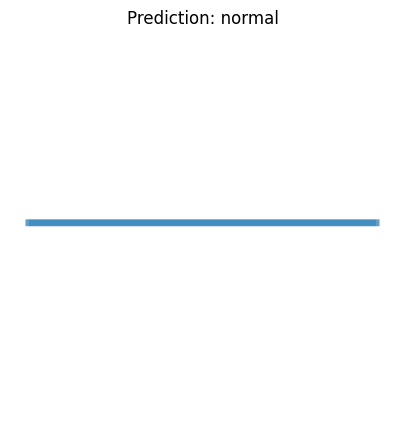

In [83]:
# ==========================================
# PREDIKSI GAMBAR
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

class_names = ["anomaly", "normal"]

IMAGE_PATH = "/kaggle/working/electricity_images/normal"

# Ambil satu gambar dari folder normal
import os

image_file = None

for file in os.listdir(IMAGE_PATH):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        image_file = os.path.join(IMAGE_PATH, file)
        break

print("Gambar:", image_file)

# Load gambar
img = tf.keras.utils.load_img(
    image_file,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = tf.expand_dims(img_array, 0)

# Prediksi
prediction = infer(img_array)["output_0"].numpy()[0][0]

predicted_class = class_names[int(prediction >= 0.5)]

print("\n=== HASIL PREDIKSI GAMBAR ===")
print("Prediksi :", predicted_class)
print("Score    :", f"{prediction:.4f}")

# Tampilkan gambar
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()